In [2]:
Project Title: Customer Data Analysis for Business Insights
Objective:
The goal of this project is to segment customers based on their purchasing behavior to improve marketing effectiveness and business decision-making.

Why RFM?
RFM analysis helps us categorize customers into distinct groups, allowing the business to:

Identify Champions: Our most valuable customers who deserve exclusive rewards.

Detect Churn Risk: Quickly spot 'At-Risk' customers and re-engage them with targeted offers.

Optimize Marketing Spend: Avoid wasting budget on 'Lost' customers and focus efforts on high-potential segments.

Methodology:

Recency (R): How recently did the customer make a purchase?

Frequency (F): How often do they purchase?

Monetary (M): How much do they spend?

In [125]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Read Customer Data
cust=pd.read_excel('/content/Customer_Master_Data.xlsx')

In [10]:
#check Shape for surity
cust.shape

(1000, 9)

In [13]:
CT=pd.read_csv('/content/Customer_Transactions.csv')

In [14]:
CT.shape

(23050, 3)

In [16]:
#Check information
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     1000 non-null   object        
 1   Name           1000 non-null   object        
 2   Email          1000 non-null   object        
 3   Gender         1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   City           1000 non-null   object        
 6   MaritalStatus  1000 non-null   object        
 7   NumChildren    1000 non-null   int64         
 8   JoinDate       1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 70.4+ KB


In [17]:
CT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), object(2)
memory usage: 540.4+ KB


In [18]:
#Importing Datetime to change date
import datetime

In [20]:
CT['TransactionDate']=pd.to_datetime(CT['TransactionDate'])

/tmp/ipykernel_268/3893966871.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  CT['TransactionDate']=pd.to_datetime(CT['TransactionDate'])


In [22]:
#Check Duplicate Values
CT.duplicated().sum()

np.int64(0)

In [24]:
# Combining customer profiles with purchase data for a complete view
merged=pd.merge(cust,CT,on='CustomerID', how='left')

In [25]:
# Checking merged Data
merged.head(15)

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,TransactionDate,TransactionAmount
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-10-03,961.52
1,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,92.16
2,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,1153.74
3,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2023-01-31,1217.04
4,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-06-12,912.08
5,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-04-21,965.11
6,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2025-07-17,467.93
7,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2025-03-02,1456.19
8,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-02-04,1299.42
9,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-03-05,1251.68


In [26]:
# Calculating 'Last Purchase Date' for each customer to analyze recency
merged.groupby('CustomerID')['TransactionDate'].max()

,TransactionDate
CustomerID,
CUST10000,2025-07-17
CUST10001,2025-06-25
CUST10002,2025-07-12
CUST10003,2025-05-10
CUST10004,2025-07-22
...,...
CUST10995,2024-06-23
CUST10996,2025-07-15
CUST10997,2025-06-28


In [27]:
# Counting total transactions per customer to calculate Frequency
merged.groupby('CustomerID')['TransactionDate'].count()

,TransactionDate
CustomerID,
CUST10000,23
CUST10001,30
CUST10002,24
CUST10003,25
CUST10004,19
...,...
CUST10995,21
CUST10996,21
CUST10997,20


In [28]:
# Calculating Total Monetary Value (Sum of TransactionAmount) for each CustomerID
merged.groupby('CustomerID')['TransactionAmount'].sum()

,TransactionAmount
CustomerID,
CUST10000,21265.49
CUST10001,28654.31
CUST10002,23884.03
CUST10003,24206.03
CUST10004,25565.30
...,...
CUST10995,24325.19
CUST10996,21809.11
CUST10997,21120.48


In [29]:
# Finding the overall maximum transaction date to calculate recency reference point
merged['TransactionDate'].max()

Timestamp('2025-07-29 00:00:00')

In [38]:
# Aggregating multiple metrics per customer to create a base for RFM analysis
merged.groupby('CustomerID').agg({'TransactionDate': ['count','max'],'TransactionAmount':'sum'}).reset_index()

CustomerID TransactionDate            TransactionAmount
                         count        max               sum
0    CUST10000              23 2025-07-17          21265.49
1    CUST10001              30 2025-06-25          28654.31
2    CUST10002              24 2025-07-12          23884.03
3    CUST10003              25 2025-05-10          24206.03
4    CUST10004              19 2025-07-22          25565.30
..         ...             ...        ...               ...
995  CUST10995              21 2024-06-23          24325.19
996  CUST10996              21 2025-07-15          21809.11
997  CUST10997              20 2025-06-28          21120.48
998  CUST10998              25 2025-03-26          29494.56
999  CUST10999              23 2025-07-25          22028.01

[1000 rows x 4 columns]

In [83]:
df_rfm=merged.groupby('CustomerID').agg({'TransactionDate': ['count','max'],'TransactionAmount':'sum'}).reset_index()

In [84]:
# Displaying the aggregated customer metrics (Recency, Frequency, Monetary)
df_rfm.columns = ['CustomerID', 'Frequency', 'Recency', 'Monetary']


In [70]:
merged['TransactionDate'] = pd.to_datetime(merged['TransactionDate'])

In [85]:
df_rfm = merged.groupby('CustomerID').agg({
    'TransactionDate': 'max',
    'TransactionAmount': 'sum',
    'CustomerID': 'count' # Frequency ke liye
}).rename(columns={'TransactionDate': 'Last_Purchase', 'TransactionAmount': 'Monetary', 'CustomerID': 'Frequency'}).reset_index()

In [88]:
snapshot_date = merged['TransactionDate'].max() + pd.Timedelta(days=1)
df_rfm['Recency'] = (snapshot_date - df_rfm['Last_Purchase']).dt.days

In [89]:
df_rfm.head()

,CustomerID,Last_Purchase,Monetary,Frequency,Recency
0,CUST10000,2025-07-17,21265.49,23,13
1,CUST10001,2025-06-25,28654.31,30,35
2,CUST10002,2025-07-12,23884.03,24,18
3,CUST10003,2025-05-10,24206.03,25,81
4,CUST10004,2025-07-22,25565.30,19,8


In [91]:
# Calculate Scoring Segment
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'], q=5, labels=[1, 2, 3, 4, 5])
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

In [92]:
df_rfm.head()

,CustomerID,Last_Purchase,Monetary,Frequency,Recency,R_Score,F_Score,M_Score
0,CUST10000,2025-07-17,21265.49,23,13,4,3,2
1,CUST10001,2025-06-25,28654.31,30,35,3,5,5
2,CUST10002,2025-07-12,23884.03,24,18,4,3,3
3,CUST10003,2025-05-10,24206.03,25,81,1,4,3
4,CUST10004,2025-07-22,25565.30,19,8,5,1,4


In [93]:
# Convert to string and concatenate
df_rfm['RFM_Score'] = df_rfm['R_Score'].astype(str) + df_rfm['F_Score'].astype(str) + df_rfm['M_Score'].astype(str)

In [94]:
df_rfm.head()

,CustomerID,Last_Purchase,Monetary,Frequency,Recency,R_Score,F_Score,M_Score,RFM_Score
0,CUST10000,2025-07-17,21265.49,23,13,4,3,2,432
1,CUST10001,2025-06-25,28654.31,30,35,3,5,5,355
2,CUST10002,2025-07-12,23884.03,24,18,4,3,3,433
3,CUST10003,2025-05-10,24206.03,25,81,1,4,3,143
4,CUST10004,2025-07-22,25565.30,19,8,5,1,4,514


In [96]:
#import numpy as np

In [98]:
# Define the segmentation logic
def assign_segment(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif f >= 4 and r >= 2:
        return 'Loyal Customers'
    elif r >= 4 and f >= 2:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r == 1 and f <= 2 and m <= 2:
        return 'Lost'
    elif m >= 4:
        return 'Big Spender'
    else:
        return 'Others'

In [99]:
# Apply the function
df_rfm['Segment'] = df_rfm.apply(assign_segment, axis=1)

In [100]:
# Display the result
df_rfm.head()

,CustomerID,Last_Purchase,Monetary,Frequency,Recency,R_Score,F_Score,M_Score,RFM_Score,Segment
0,CUST10000,2025-07-17,21265.49,23,13,4,3,2,432,Potential Loyalist
1,CUST10001,2025-06-25,28654.31,30,35,3,5,5,355,Loyal Customers
2,CUST10002,2025-07-12,23884.03,24,18,4,3,3,433,Potential Loyalist
3,CUST10003,2025-05-10,24206.03,25,81,1,4,3,143,At Risk
4,CUST10004,2025-07-22,25565.30,19,8,5,1,4,514,Big Spender


In [101]:
df_rfm['Segment'].value_counts()

,count
Segment,
Others,268
Loyal Customers,191
Potential Loyalist,167
At Risk,130
Champions,127
Lost,76
Big Spender,41


In [102]:
df_rfm

,CustomerID,Last_Purchase,Monetary,Frequency,Recency,R_Score,F_Score,M_Score,RFM_Score,Segment
0,CUST10000,2025-07-17,21265.49,23,13,4,3,2,432,Potential Loyalist
1,CUST10001,2025-06-25,28654.31,30,35,3,5,5,355,Loyal Customers
2,CUST10002,2025-07-12,23884.03,24,18,4,3,3,433,Potential Loyalist
3,CUST10003,2025-05-10,24206.03,25,81,1,4,3,143,At Risk
4,CUST10004,2025-07-22,25565.30,19,8,5,1,4,514,Big Spender
...,...,...,...,...,...,...,...,...,...,...
995,CUST10995,2024-06-23,24325.19,21,402,1,2,3,123,Others
996,CUST10996,2025-07-15,21809.11,21,15,4,2,3,423,Potential Loyalist
997,CUST10997,2025-06-28,21120.48,20,32,3,2,2,322,Others
998,CUST10998,2025-03-26,29494.56,25,126,1,4,5,145,At Risk


In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
# Count the customers per segment and sort by count
segment_counts = df_rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

/tmp/ipykernel_268/1311581548.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rfm, x='Segment', order=df_rfm['Segment'].value_counts().index, palette='viridis')


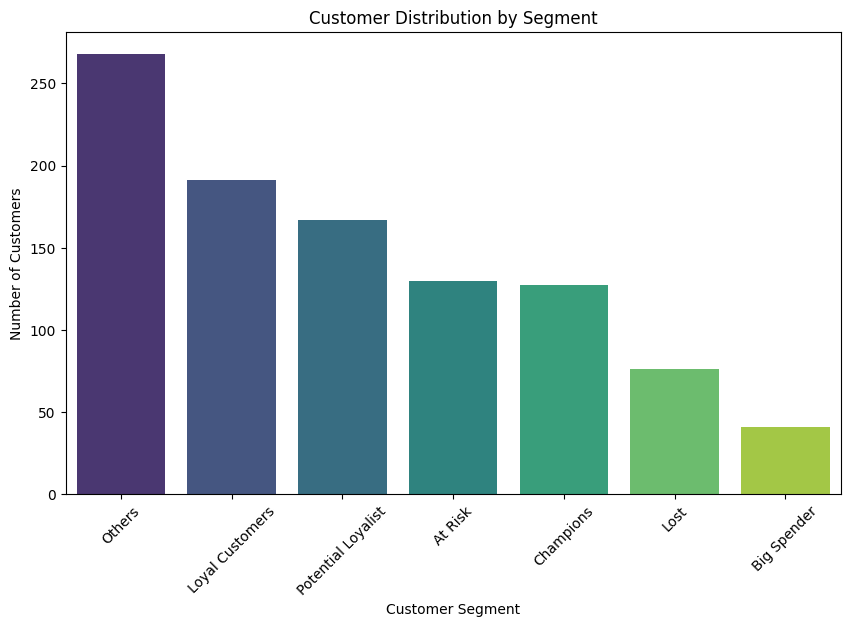

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar chart
plt.figure(figsize=(10, 6))

# sns.countplot automatically performs value counts and plots the distribution
sns.countplot(data=df_rfm, x='Segment', order=df_rfm['Segment'].value_counts().index, palette='viridis')

plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_268/587228979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_per_segment, x='Segment', y='Monetary', palette='magma')


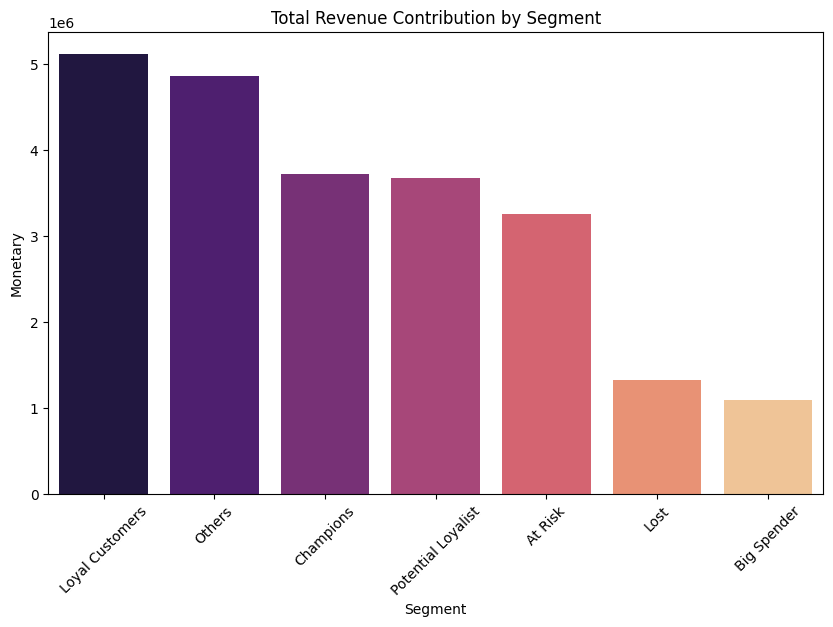

In [114]:
# Revenue Contribution per Segment
# Group by Segment and sum Monetary
revenue_per_segment = df_rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_per_segment, x='Segment', y='Monetary', palette='magma')
plt.title('Total Revenue Contribution by Segment')
plt.xticks(rotation=45)
plt.show()

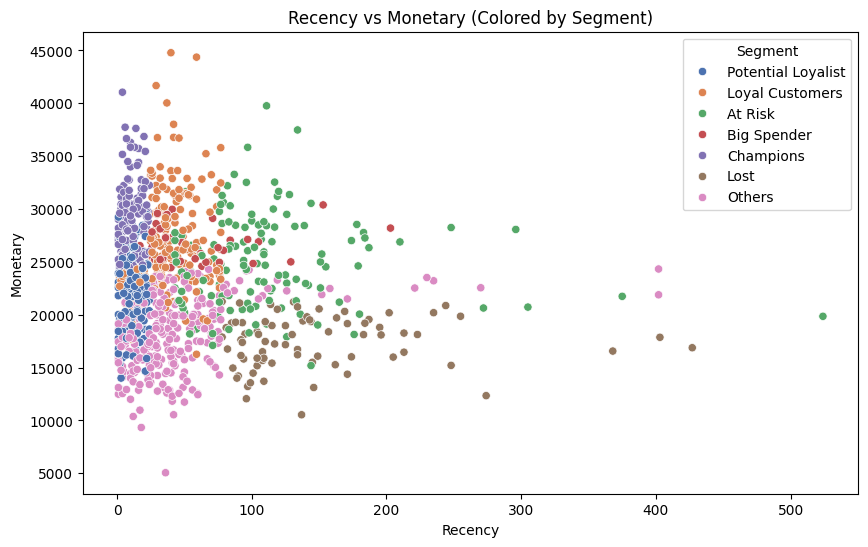

In [115]:
# Recency vs. Monetary (Color-coded by Segment)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_rfm, x='Recency', y='Monetary', hue='Segment', palette='deep')
plt.title('Recency vs Monetary (Colored by Segment)')
plt.show()

In [116]:
# Pareto Analysis (The 80/20 Rule)


In [117]:
# Calculate % of total revenue
df_sorted = df_rfm.sort_values(by='Monetary', ascending=False)
df_sorted['Cumulative_Revenue'] = df_sorted['Monetary'].cumsum()
total_revenue = df_sorted['Monetary'].sum()
df_sorted['Cumulative_Percentage'] = (df_sorted['Cumulative_Revenue'] / total_revenue) * 100

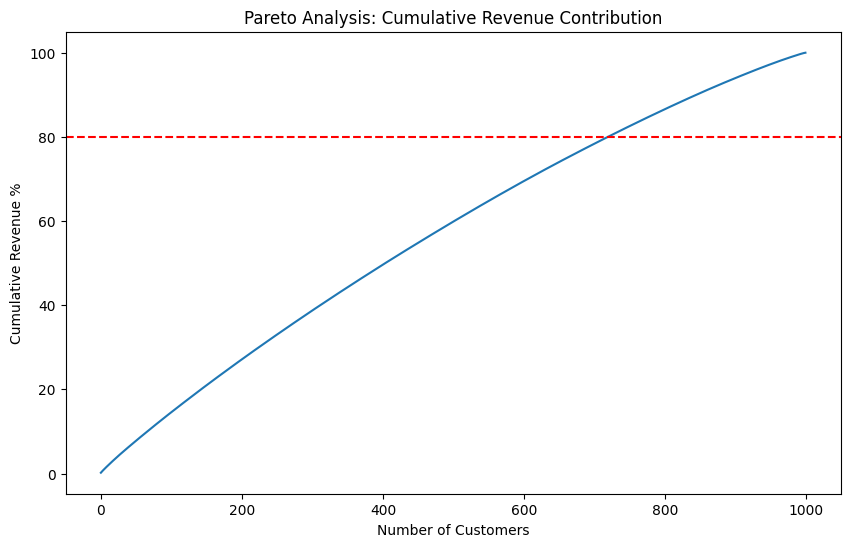

In [118]:
# Plotting the curve
plt.figure(figsize=(10, 6))
plt.plot(range(len(df_sorted)), df_sorted['Cumulative_Percentage'])
plt.axhline(80, color='red', linestyle='--') # 80% line
plt.title('Pareto Analysis: Cumulative Revenue Contribution')
plt.xlabel('Number of Customers')
plt.ylabel('Cumulative Revenue %')
plt.show()

In [119]:
df_rfm['Segment'].value_counts()

,count
Segment,
Others,268
Loyal Customers,191
Potential Loyalist,167
At Risk,130
Champions,127
Lost,76
Big Spender,41


In [120]:
# Mapping: Segment -> Action Plan
action_mapping = {
    'Champions': 'Send early access offers & premium loyalty rewards',
    'Loyal Customers': 'Send reward points, upsell new products',
    'Potential Loyalist': 'Offer welcome packs & personalized recommendations',
    'Big Spenders': 'Invite to exclusive loyalty tier, nurture for referrals',
    'At Risk': 'Send re-engagement discount coupons (e.g., 20% off)',
    'Lost': 'Consider exit surveys, remove from regular email lists',
    'Others': 'Standard monthly newsletters'}

In [121]:
# Add new column
df_rfm['Action_Plan'] = df_rfm['Segment'].map(action_mapping)

In [122]:
# Final Check
print(df_rfm[['Segment', 'Action_Plan']].head())

              Segment                                        Action_Plan
0  Potential Loyalist  Offer welcome packs & personalized recommendat...
1     Loyal Customers            Send reward points, upsell new products
2  Potential Loyalist  Offer welcome packs & personalized recommendat...
3             At Risk  Send re-engagement discount coupons (e.g., 20%...
4         Big Spender                                                NaN


In [127]:
df_rfm.head()

,CustomerID,Last_Purchase,Monetary,Frequency,Recency,R_Score,F_Score,M_Score,RFM_Score,Segment,Action_Plan
0,CUST10000,2025-07-17,21265.49,23,13,4,3,2,432,Potential Loyalist,Offer welcome packs & personalized recommendat...
1,CUST10001,2025-06-25,28654.31,30,35,3,5,5,355,Loyal Customers,"Send reward points, upsell new products"
2,CUST10002,2025-07-12,23884.03,24,18,4,3,3,433,Potential Loyalist,Offer welcome packs & personalized recommendat...
3,CUST10003,2025-05-10,24206.03,25,81,1,4,3,143,At Risk,"Send re-engagement discount coupons (e.g., 20%..."
4,CUST10004,2025-07-22,25565.30,19,8,5,1,4,514,Big Spender,NaN


In [131]:
# Generate the final summary table to evaluate segment performance
df_summary = df_rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Monetary': 'mean',
    'Frequency': 'mean',
    'Recency': 'mean'
}).rename(columns={
    'CustomerID': 'Number_of_Customers',
    'Monetary': 'Avg_Monetary',
    'Frequency': 'Avg_Frequency',
    'Recency': 'Avg_Recency'
})

In [132]:
# Display the summary table for quick inspection
print(df_summary)

                    Number_of_Customers  Avg_Monetary  Avg_Frequency  \
Segment                                                                
At Risk                             130  25054.506692      25.207692   
Big Spender                          41  26561.015854      21.780488   
Champions                           127  29331.846772      28.645669   
Lost                                 76  17410.040000      18.118421   
Loyal Customers                     191  26819.926702      27.659686   
Others                              268  18139.340970      18.250000   
Potential Loyalist                  167  22005.120838      22.101796   

                    Avg_Recency  
Segment                          
At Risk              111.469231  
Big Spender           55.487805  
Champions             10.692913  
Lost                 148.407895  
Loyal Customers       39.413613  
Others                44.611940  
Potential Loyalist    11.419162  


In [134]:
# Export the summary to a CSV file for reporting
df_summary.to_csv('rfm_segment_summary.csv')